In [29]:
import requests
import csv
import pandas as pd
import math
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import time
import random
from datetime import datetime, date
import statistics
import requests
from scipy.stats import skew, kurtosis
from scipy import stats
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from scipy.stats import johnsonsu
from scipy.optimize import minimize
from scipy.stats import norm

In [30]:
def get_data(ticker, size='full', date_filter=None):
    """ Retrieve time series data for the price of a security in data frame format
        Sorts so that first date is first index, filters on date if given, renames columns and converts datatypes

    Args:
        ticker (string): The ticker for the security to pull data from
        size (string): 'full' since 1999, 'compact' is last 100 trading days
        date_filter (date string): Filters  data to  keep data only the filter date onward

    Returns:
        df: A dataframe with open, close, high, low, adj close price, volume, split coef, date
    """
    key='&apikey=ZKMMTO1ATDBLXH2K' # API Key
    api_ticker=f'&symbol={ticker}' # Ticker
    endpoint='function=TIME_SERIES_DAILY_ADJUSTED' # Called 'function', the dataset we want
    size=f'&outputsize={size}'
    web='https://www.alphavantage.co/query?'
    url =web+endpoint+api_ticker+size+key

    r = requests.get(url)
    # print(r.status_code) # 200 good, 400 bad
    data = r.json()

    # print(data.keys()) #printing the keys
    meta = data['Meta Data']
    time_series_data = data['Time Series (Daily)']

    ts_df = pd.DataFrame.from_dict(time_series_data, orient='index').reset_index().rename(columns={'index': 'Date'})
    clean_cols_dict = {'1. open': 'Open', '2. high': 'High', '3. low': 'Low', '4. close': 'Close', # Dictionary to convert the names of the columns
                '5. adjusted close': 'Adj Close', '6. volume': 'Volume', '7. dividend amount': 'Dividend', '8. split coefficient': 'Split Coef'}
    ts_df = ts_df.rename(columns=clean_cols_dict)

    ts_df['Date'] = pd.to_datetime(ts_df['Date'])
    if date_filter is not None:
        date_filter = pd.to_datetime(date_filter)
        ts_df = ts_df[ts_df['Date'] >= date_filter]


    ts_df = ts_df.sort_values(by='Date', ascending=True).reset_index().drop(columns='index')
    ts_df['Adj Close'] = ts_df['Adj Close'].astype('float').round(4)
    ts_df['Ticker'] = ticker
    
    return ts_df

In [31]:
def calculate_returns(df, frequency=1):
    """ Calculate the log returns of a security given a df with its prices over a time period

    Args:
        df (dataframe): A dataframe with columns Date, Ticker, Volume, and Adj Close
        frequency (int, optional): How often you want to calculate a return Defaults to 1.

    Returns:
        df: The dataframe from the start with an additional 'Log Return' column which is the log return over the interval for each row
    """
    returns_df = df[['Date', 'Ticker', 'Volume', 'Adj Close']].copy()
    returns_df['Adj Close'] = returns_df['Adj Close'].astype('float')
    returns_df['Log Return'] = np.log(
        returns_df['Adj Close'] / returns_df['Adj Close'].shift(frequency)
    )
    returns_df = returns_df.dropna()

    # If frequency > 1, keep only every `frequency`-th row
    if frequency > 1:
        returns_df = returns_df.iloc[frequency-1::frequency].reset_index(drop=True)

    return returns_df



In [32]:
coke_df = get_data('KO', size='full', date_filter='2021-01-01')
coke_df = coke_df[coke_df['Date'] <= pd.to_datetime('2026-01-01')]
returns_df = calculate_returns(coke_df, frequency=1).rename(columns={'Adj Close': 'Price'})
returns_df

ConnectionError: HTTPSConnectionPool(host='www.alphavantage.co', port=443): Max retries exceeded with url: /query?function=TIME_SERIES_DAILY_ADJUSTED&symbol=KO&outputsize=full&apikey=ZKMMTO1ATDBLXH2K (Caused by NameResolutionError("HTTPSConnection(host='www.alphavantage.co', port=443): Failed to resolve 'www.alphavantage.co' ([Errno 8] nodename nor servname provided, or not known)"))

In [22]:
# Bootstrap standard errors and 95% CIs for mean and volatility (daily std of log returns)
r = returns_df['Log Return'].dropna().values
r_sq = r**2
# ACF of KO daily log returns

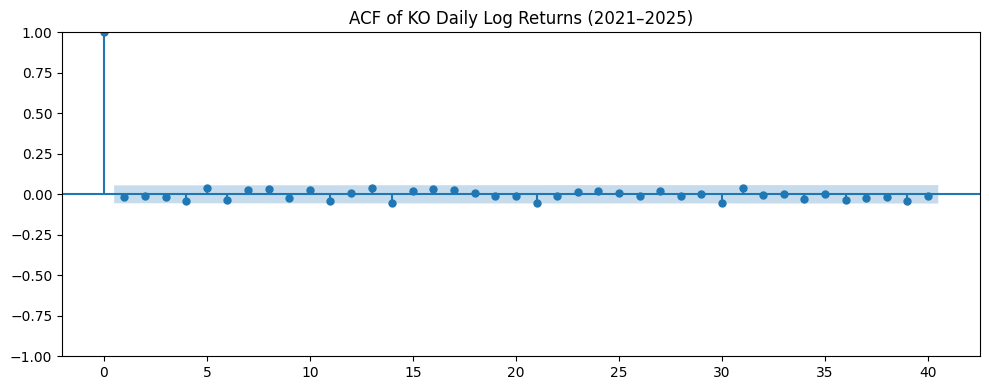

In [23]:
# ACF of KO daily log returns
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(r, lags=40, ax=ax)
ax.set_title('ACF of KO Daily Log Returns (2021–2025)')
plt.tight_layout()
plt.show()

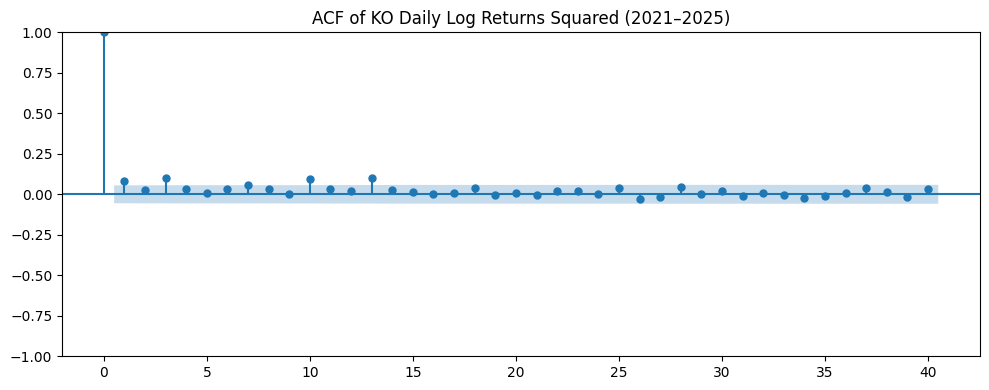

In [24]:
# ACF of KO daily log returns squared
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(r_sq, lags=40, ax=ax)
ax.set_title('ACF of KO Daily Log Returns Squared (2021–2025)')
plt.tight_layout()
plt.show()

Ljung-Box on KO daily log returns (r)
H0: no autocorrelation in the mean

    lb_stat  lb_pvalue
10  10.3951     0.4065
15  19.3666     0.1976
20  22.4241     0.3179

Ljung-Box on KO daily squared log returns (r²)
H0: no autocorrelation in squared returns (vol clustering)

    lb_stat  lb_pvalue
10  41.4410        0.0
15  57.6773        0.0
20  59.8878        0.0


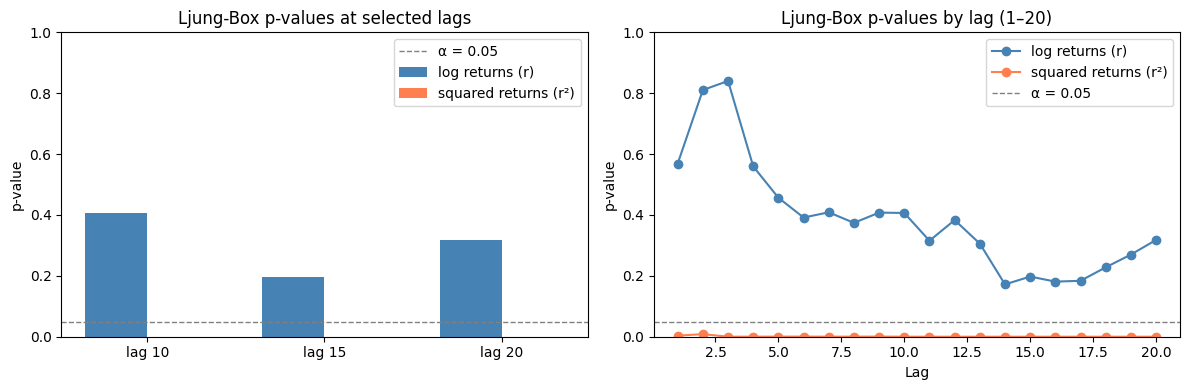

In [25]:
# Ljung-Box test: joint test for autocorrelation up to lag k
# H0: all autocorrelations ρ_1 ... ρ_k are zero
from statsmodels.stats.diagnostic import acorr_ljungbox

test_lags = [10, 15, 20]

lb_r = acorr_ljungbox(r, lags=test_lags, return_df=True)
lb_r_sq = acorr_ljungbox(r_sq, lags=test_lags, return_df=True)

print("Ljung-Box on KO daily log returns (r)")
print("H0: no autocorrelation in the mean\n")
print(lb_r.round(4))
print()

print("Ljung-Box on KO daily squared log returns (r²)")
print("H0: no autocorrelation in squared returns (vol clustering)\n")
print(lb_r_sq.round(4))

# p-values across lags 1–20 for plotting
lb_r_by_lag = acorr_ljungbox(r, lags=20, return_df=True)
lb_r_sq_by_lag = acorr_ljungbox(r_sq, lags=20, return_df=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grouped bar chart at selected lags
x = np.arange(len(test_lags))
width = 0.35
axes[0].bar(x - width / 2, lb_r['lb_pvalue'], width, label='log returns (r)', color='steelblue')
axes[0].bar(x + width / 2, lb_r_sq['lb_pvalue'], width, label='squared returns (r²)', color='coral')
axes[0].axhline(0.05, color='gray', linestyle='--', linewidth=1, label='α = 0.05')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'lag {k}' for k in test_lags])
axes[0].set_ylabel('p-value')
axes[0].set_title('Ljung-Box p-values at selected lags')
axes[0].legend()
axes[0].set_ylim(0, 1)

# p-value vs lag (lags 1–20)
axes[1].plot(lb_r_by_lag.index, lb_r_by_lag['lb_pvalue'], marker='o', label='log returns (r)', color='steelblue')
axes[1].plot(lb_r_sq_by_lag.index, lb_r_sq_by_lag['lb_pvalue'], marker='o', label='squared returns (r²)', color='coral')
axes[1].axhline(0.05, color='gray', linestyle='--', linewidth=1, label='α = 0.05')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('p-value')
axes[1].set_title('Ljung-Box p-values by lag (1–20)')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

AR(1) coefficient on lagged return
  φ₁ = -0.016076
  p-value = 0.4844

   Model        AIC        BIC  ΔAIC vs AR(0)  ΔBIC vs AR(0)
0  AR(0) -7991.6452 -7981.3770         0.0000         0.0000
1  AR(1) -7989.9701 -7974.5678         1.6751         6.8092


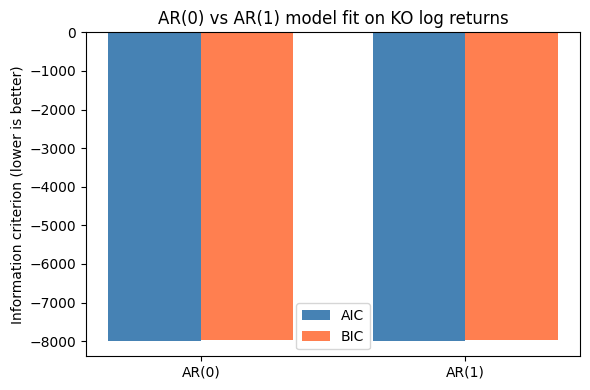

In [27]:
# AR(0) vs AR(1) on KO daily log returns
from statsmodels.tsa.arima.model import ARIMA

ar0 = ARIMA(r, order=(0, 0, 0)).fit()
ar1 = ARIMA(r, order=(1, 0, 0)).fit()

# params/pvalues are numpy arrays in some statsmodels versions — map names explicitly
ar1_params = pd.Series(ar1.params, index=ar1.param_names)
ar1_pvalues = pd.Series(ar1.pvalues, index=ar1.param_names)

phi1 = ar1_params['ar.L1']
phi1_pval = ar1_pvalues['ar.L1']

comparison = pd.DataFrame({
    'Model': ['AR(0)', 'AR(1)'],
    'AIC': [ar0.aic, ar1.aic],
    'BIC': [ar0.bic, ar1.bic],
})
comparison['ΔAIC vs AR(0)'] = comparison['AIC'] - ar0.aic
comparison['ΔBIC vs AR(0)'] = comparison['BIC'] - ar0.bic

print('AR(1) coefficient on lagged return')
print(f'  φ₁ = {phi1:.6f}')
print(f'  p-value = {phi1_pval:.4f}')
print()
print(comparison.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
width = 0.35
ax.bar(x - width / 2, comparison['AIC'], width, label='AIC', color='steelblue')
ax.bar(x + width / 2, comparison['BIC'], width, label='BIC', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.set_ylabel('Information criterion (lower is better)')
ax.set_title('AR(0) vs AR(1) model fit on KO log returns')
ax.legend()
plt.tight_layout()
plt.show()

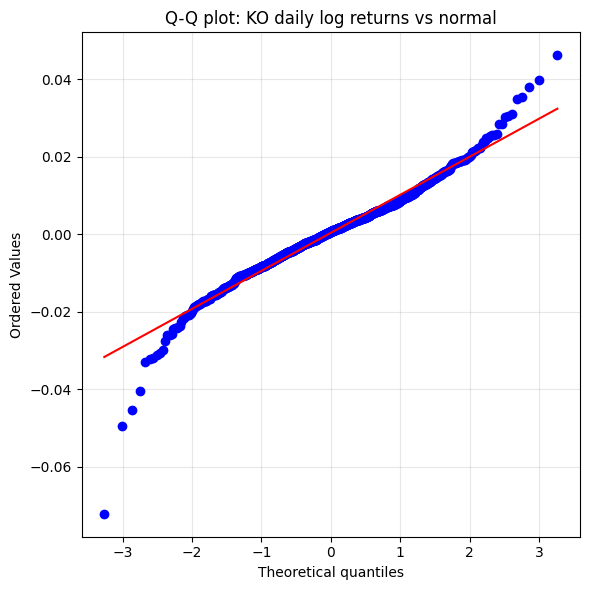

In [28]:
# Q-Q plot: sample quantiles vs theoretical normal quantiles
from scipy import stats

fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(r, dist='norm', plot=ax)
ax.set_title('Q-Q plot: KO daily log returns vs normal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()